In [9]:
import os

base_path = "data1/raw/brain_tumor"

for split in ["Training", "Testing"]:
    print(f"\n{split}:")

    for category in os.listdir(os.path.join(base_path, split)):
        path = os.path.join(base_path, split, category)
        print(category, "->", len(os.listdir(path)), "images")


Training:
glioma -> 1400 images
meningioma -> 1400 images
notumor -> 1400 images
pituitary -> 1400 images

Testing:
glioma -> 400 images
meningioma -> 400 images
notumor -> 400 images
pituitary -> 400 images


In [10]:
import cv2
import numpy as np
from tqdm import tqdm
import random

In [11]:
IMG_SIZE = 224
CATEGORIES = ["glioma", "meningioma", "pituitary", "notumor"]

DATA_DIR = "data1/raw/brain_tumor/Training"

In [12]:
data = []

for category in CATEGORIES:
    path = os.path.join(DATA_DIR, category)
    label = CATEGORIES.index(category)

    for img in tqdm(os.listdir(path)):
        try:
            img_path = os.path.join(path, img)

            img_array = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

            resized = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))

            data.append([resized, label])
        except:
            pass

print("Total images loaded:", len(data))

100%|█████████████████████████████████████████████████████████████████████████████| 1400/1400 [00:05<00:00, 259.07it/s]

Total images loaded: 5600


In [13]:
random.shuffle(data)

In [14]:
X = []
y = []

for features, label in data:
    X.append(features)
    y.append(label)

X = np.array(X)
y = np.array(y)

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (5600, 224, 224)
Shape of y: (5600,)


In [15]:
X = X.reshape(-1, IMG_SIZE, IMG_SIZE, 1)

In [16]:
X = X / 255.0

In [17]:
print("X shape:", X.shape)
print("Single image:", X[0].shape)
print("Min:", X.min(), "Max:", X.max())

X shape: (5600, 224, 224, 1)
Single image: (224, 224, 1)
Min: 0.0 Max: 1.0


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)

Train: (4480, 224, 224, 1)
Validation: (1120, 224, 224, 1)


In [20]:
def load_test_data(folder):
    data = []

    for category in CATEGORIES:
        path = os.path.join(folder, category)
        label = CATEGORIES.index(category)

        for img in os.listdir(path):
            try:
                img_path = os.path.join(path, img)
                img_array = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                resized = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
                data.append([resized, label])
            except:
                pass

    X_test, y_test = [], []
    for features, label in data:
        X_test.append(features)
        y_test.append(label)

    X_test = np.array(X_test).reshape(-1, IMG_SIZE, IMG_SIZE, 1) / 255.0
    y_test = np.array(y_test)

    return X_test, y_test

In [21]:
X_test, y_test = load_test_data("data1/raw/brain_tumor/Testing")

print("Test shape:", X_test.shape)

Test shape: (1600, 224, 224, 1)


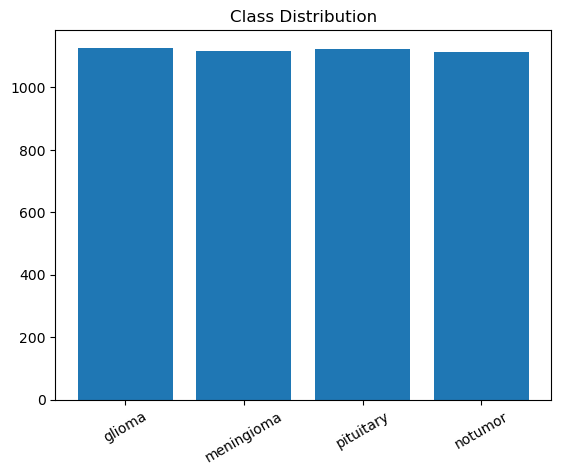

In [22]:
import matplotlib.pyplot as plt
import numpy as np

unique, counts = np.unique(y_train, return_counts=True)

plt.bar(CATEGORIES, counts)
plt.title("Class Distribution")
plt.xticks(rotation=30)
plt.show()

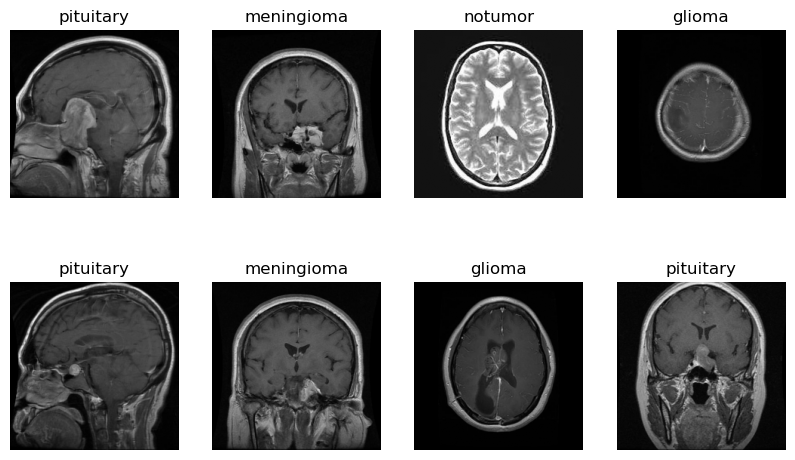

In [23]:
plt.figure(figsize=(10,6))

for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(X_train[i].reshape(224,224), cmap='gray')
    plt.title(CATEGORIES[y_train[i]])
    plt.axis('off')

plt.show()

In [24]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

datagen.fit(X_train)

In [25]:
import pickle

pickle.dump(X_train, open("data1/processed/brain_X_train.pkl", "wb"))
pickle.dump(y_train, open("data1/processed/brain_y_train.pkl", "wb"))

pickle.dump(X_val, open("data1/processed/brain_X_val.pkl", "wb"))
pickle.dump(y_val, open("data1/processed/brain_y_val.pkl", "wb"))

pickle.dump(X_test, open("data1/processed/brain_X_test.pkl", "wb"))
pickle.dump(y_test, open("data1/processed/brain_y_test.pkl", "wb"))

print("Saved!")

Saved!


In [26]:
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

In [27]:
print("Dataset shape:", X_train.shape)
print("Single image shape:", X_train[0].shape)

Dataset shape: (4480, 224, 224, 1)
Single image shape: (224, 224, 1)


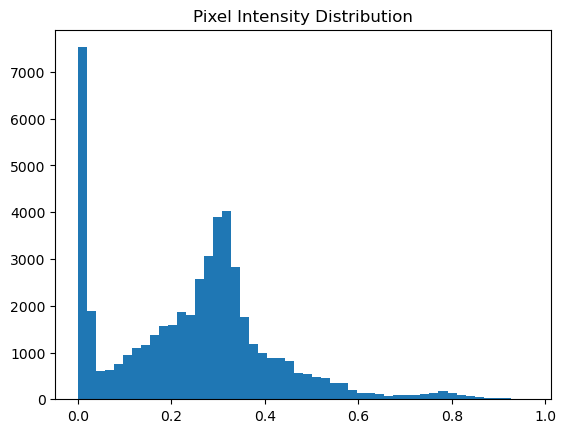

In [28]:
plt.figure()
plt.hist(X_train[0].ravel(), bins=50)
plt.title("Pixel Intensity Distribution")
plt.show()

In [29]:
print("Min pixel value:", X_train.min())
print("Max pixel value:", X_train.max())

Min pixel value: 0.0
Max pixel value: 1.0


In [30]:
print("Total training samples:", len(X_train))
print("Total validation samples:", len(X_val))

Total training samples: 4480
Total validation samples: 1120


In [34]:
import os
categories = os.listdir("data1/raw/brain_tumor/Training")
for i, cat in enumerate(categories):
    print(f"{cat}: {(y_train == i).sum()} images")

glioma: 1127 images
meningioma: 1116 images
notumor: 1123 images
pituitary: 1114 images


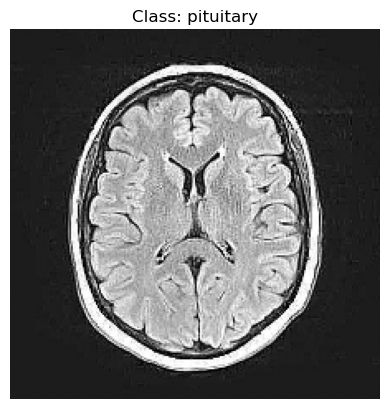

In [35]:
import random

idx = random.randint(0, len(X_train)-1)

plt.imshow(X_train[idx].reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
plt.title(f"Class: {categories[y_train[idx]]}")
plt.axis('off')
plt.show()